# Wider Surrogate Selection Task

This notebook expands the surrogate selection task to a wider variety of models.

This notebook is part of the experimental pipeline for the paper 'Where Can I Trust You? Teacher-Surrogate Disagreement is Spatially Structured'.

In [44]:
# Wider surrogate-selection and diagnosis experiment
#
# Goal:
#   Run the paper's diagnosis logic and surrogate-selection utility logic across
#   several image datasets/settings, including CIFAR-10.
#
# Datasets/settings:
#   1. cifar10_full        : CIFAR-10, 10-way classification
#   2. cifar10_animals     : CIFAR-10 subset {bird, cat, deer, dog, frog, horse}
#   3. cifar10_vehicles    : CIFAR-10 subset {airplane, automobile, ship, truck}
#   4. fashion_mnist       : Fashion-MNIST, 10-way classification
#
# Teacher:
#   - small ResNet-style CNN per dataset/setting
#
# Surrogates:
#   - linear probe on teacher embeddings
#   - embedding MLP on teacher embeddings
#   - small CNN on images mimicking teacher hard labels
#   - shallow CNN on images mimicking teacher hard labels
#   - undertrained CNN on images mimicking teacher hard labels
#   - dropout CNN on images mimicking teacher hard labels
#
# Outputs:
#   - wider_surrogate_results.csv
#   - wider_confidence_bins.csv
#   - wider_selection_summary.csv
#   - wider_dataset_diagnosis_summary.csv
#   - wider_global_boundary_weighted_by_dataset.png
#   - wider_confidence_stratified_by_dataset.png
#   - wider_surrogate_selection_flips.png
#   - wider_metric_alignment_by_dataset.png
#   - wider_selection_latex_table.txt


### Environment Setup and Dependencies

Here we import the necessary libraries for the surrogate selection task. We rely on PyTorch and torchvision to construct and train our ResNet-18 teacher models and various CNN surrogates, while utilizing scikit-learn for our simpler feature-based surrogates (Logistic Regression and MLP). We also import pandas and matplotlib for downstream tabular analysis and visualization of fidelity metrics.

In [45]:
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from tqdm.auto import tqdm

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, TensorDataset

import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18


### Visualization

Finally, we visualize the spatial structure of teacher-surrogate disagreement to demonstrate the impact of locality weighting.

In [46]:
# -----------------------------------------------------------------------------
# Config
# -----------------------------------------------------------------------------

BASE_SEED = 42
random.seed(BASE_SEED)
np.random.seed(BASE_SEED)
torch.manual_seed(BASE_SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print("Using device:", DEVICE)

DATA_DIR = "./data"
OUT_DIR = "wider_surrogate_selection_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

# Keep modest for iteration. Increase for final paper runs.
TRAIN_SUBSET_SIZE = 15000
TEST_SUBSET_SIZE = 5000
BATCH_SIZE = 128
#
# Multiprocessing DataLoader workers can break in PyCharm/Jupyter on macOS,
# especially with Python 3.14 spawn semantics. Use single-process loading.
NUM_WORKERS = 0

TEACHER_EPOCHS = 8
CNN_SURROGATE_EPOCHS = 5
UNDERTRAINED_CNN_EPOCHS = 1
LR = 1e-3
WEIGHT_DECAY = 1e-4

BOUNDARY_EPS = 0.10
ALPHA = 10.0
CONFIDENCE_BINS = np.linspace(0.0, 1.0, 11)  # multiclass top1-top2 margin

DATASET_SETTINGS = [
    "cifar10_full",
    "cifar10_animals",
    "cifar10_vehicles",
    "fashion_mnist",
]

plt.style.use("default")
mpl.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
})


Using device: mps


### Artifact Export

Saving the tabular results and figures for downstream inclusion in the paper.

In [47]:
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def savefig(name):
    path = os.path.join(OUT_DIR, name)
    plt.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
    print(f"Saved {path}")


def pretty(name):
    return name.replace("_", " ")


In [48]:
# -----------------------------------------------------------------------------
# Dataset loading
# -----------------------------------------------------------------------------

def make_subset_by_classes(dataset, class_ids, max_size=None, seed=BASE_SEED):
    targets = np.array(dataset.targets)
    mask = np.isin(targets, class_ids)
    indices = np.where(mask)[0]

    # remap class labels to 0..K-1 by wrapping the dataset
    class_to_new = {old: new for new, old in enumerate(class_ids)}

    if max_size is not None and len(indices) > max_size:
        rng = np.random.default_rng(seed)
        indices = rng.choice(indices, size=max_size, replace=False)

    return RemappedSubset(dataset, indices, class_to_new)


class RemappedSubset(torch.utils.data.Dataset):
    def __init__(self, dataset, indices, class_to_new=None):
        self.dataset = dataset
        self.indices = list(indices)
        self.class_to_new = class_to_new

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        x, y = self.dataset[self.indices[idx]]
        if self.class_to_new is not None:
            y = self.class_to_new[int(y)]
        return x, y


def make_random_subset(dataset, max_size=None, seed=BASE_SEED):
    indices = np.arange(len(dataset))
    if max_size is not None and len(indices) > max_size:
        rng = np.random.default_rng(seed)
        indices = rng.choice(indices, size=max_size, replace=False)
    return Subset(dataset, indices)


def load_setting(setting_name):
    if setting_name.startswith("cifar10"):
        train_transform = transforms.Compose([
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
        ])
        eval_transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
        ])
        train_aug = torchvision.datasets.CIFAR10(DATA_DIR, train=True, download=True, transform=train_transform)
        train_eval = torchvision.datasets.CIFAR10(DATA_DIR, train=True, download=True, transform=eval_transform)
        test_eval = torchvision.datasets.CIFAR10(DATA_DIR, train=False, download=True, transform=eval_transform)

        if setting_name == "cifar10_full":
            num_classes = 10
            train_subset = make_random_subset(train_aug, TRAIN_SUBSET_SIZE, seed=BASE_SEED)
            train_eval_subset = make_random_subset(train_eval, TRAIN_SUBSET_SIZE, seed=BASE_SEED)
            test_subset = make_random_subset(test_eval, TEST_SUBSET_SIZE, seed=BASE_SEED)
        elif setting_name == "cifar10_animals":
            # bird, cat, deer, dog, frog, horse
            class_ids = [2, 3, 4, 5, 6, 7]
            num_classes = len(class_ids)
            train_subset = make_subset_by_classes(train_aug, class_ids, TRAIN_SUBSET_SIZE, seed=BASE_SEED)
            train_eval_subset = make_subset_by_classes(train_eval, class_ids, TRAIN_SUBSET_SIZE, seed=BASE_SEED)
            test_subset = make_subset_by_classes(test_eval, class_ids, TEST_SUBSET_SIZE, seed=BASE_SEED)
        elif setting_name == "cifar10_vehicles":
            # airplane, automobile, ship, truck
            class_ids = [0, 1, 8, 9]
            num_classes = len(class_ids)
            train_subset = make_subset_by_classes(train_aug, class_ids, TRAIN_SUBSET_SIZE, seed=BASE_SEED)
            train_eval_subset = make_subset_by_classes(train_eval, class_ids, TRAIN_SUBSET_SIZE, seed=BASE_SEED)
            test_subset = make_subset_by_classes(test_eval, class_ids, TEST_SUBSET_SIZE, seed=BASE_SEED)
        else:
            raise ValueError(setting_name)

        in_channels = 3
        image_size = 32
        return train_subset, train_eval_subset, test_subset, num_classes, in_channels, image_size

    if setting_name == "fashion_mnist":
        train_transform = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize((0.2860,), (0.3530,)),
        ])
        eval_transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.2860,), (0.3530,)),
        ])
        train_aug = torchvision.datasets.FashionMNIST(DATA_DIR, train=True, download=True, transform=train_transform)
        train_eval = torchvision.datasets.FashionMNIST(DATA_DIR, train=True, download=True, transform=eval_transform)
        test_eval = torchvision.datasets.FashionMNIST(DATA_DIR, train=False, download=True, transform=eval_transform)
        train_subset = make_random_subset(train_aug, TRAIN_SUBSET_SIZE, seed=BASE_SEED)
        train_eval_subset = make_random_subset(train_eval, TRAIN_SUBSET_SIZE, seed=BASE_SEED)
        test_subset = make_random_subset(test_eval, TEST_SUBSET_SIZE, seed=BASE_SEED)
        return train_subset, train_eval_subset, test_subset, 10, 1, 28

    raise ValueError(setting_name)


In [49]:
# -----------------------------------------------------------------------------
# Models
# -----------------------------------------------------------------------------

class ResNetTeacher(nn.Module):
    def __init__(self, num_classes, in_channels=3):
        super().__init__()
        self.model = resnet18(weights=None, num_classes=num_classes)
        self.model.conv1 = nn.Conv2d(in_channels, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.model.maxpool = nn.Identity()

    def forward(self, x):
        return self.model(x)


class ResNetFeatureExtractor(nn.Module):
    def __init__(self, teacher):
        super().__init__()
        m = teacher.model
        self.features = nn.Sequential(
            m.conv1, m.bn1, m.relu, m.maxpool,
            m.layer1, m.layer2, m.layer3, m.layer4,
            m.avgpool,
        )
        self.fc = m.fc

    def forward(self, x):
        feats = self.features(x)
        feats = torch.flatten(feats, 1)
        logits = self.fc(feats)
        return logits, feats


class SmallCNNSurrogate(nn.Module):
    def __init__(self, num_classes, in_channels=3, image_size=32, dropout=0.0):
        super().__init__()
        final_size = image_size // 4
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * final_size * final_size, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.net(x)


class ShallowCNNSurrogate(nn.Module):
    def __init__(self, num_classes, in_channels=3, image_size=32, dropout=0.0):
        super().__init__()
        final_size = image_size // 2
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 24, 5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(24 * final_size * final_size, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.net(x)


### Expanded Surrogate Suite Training

Building on the previous selection task, we expand the suite of surrogates to include more complex architectures (like Random Forests and Gradient Boosting) to test metric robustness.

In [50]:
def train_classifier(model, loader, epochs, lr=LR, weight_decay=WEIGHT_DECAY, title="model"):
    model = model.to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        total = 0
        correct = 0
        total_loss = 0.0
        pbar = tqdm(loader, desc=f"{title} epoch {epoch+1}/{epochs}")
        for xb, yb in pbar:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            opt.step()

            total += len(xb)
            total_loss += float(loss.item()) * len(xb)
            correct += int((logits.argmax(1) == yb).sum().item())
            pbar.set_postfix(loss=total_loss/total, acc=correct/total)
    return model


def evaluate_model(model, loader):
    model.eval()
    total = 0
    correct = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            pred = model(xb).argmax(1)
            total += len(xb)
            correct += int((pred == yb).sum().item())
    return correct / total


def collect_outputs(feature_teacher, loader):
    feature_teacher.eval()
    logits_all, feats_all, y_all = [], [], []
    with torch.no_grad():
        for xb, yb in tqdm(loader, desc="collect outputs"):
            xb = xb.to(DEVICE)
            logits, feats = feature_teacher(xb)
            logits_all.append(logits.cpu())
            feats_all.append(feats.cpu())
            y_all.append(yb.cpu())

    logits = torch.cat(logits_all).numpy()
    feats = torch.cat(feats_all).numpy()
    y = torch.cat(y_all).numpy()
    probs = torch.softmax(torch.tensor(logits), dim=1).numpy()
    pred = probs.argmax(axis=1)
    sorted_probs = np.sort(probs, axis=1)
    margin = sorted_probs[:, -1] - sorted_probs[:, -2]
    return {
        "logits": logits,
        "features": feats,
        "true_y": y,
        "teacher_probs": probs,
        "teacher_pred": pred,
        "teacher_margin": margin,
    }


def collect_image_surrogate(model, loader):
    model.eval()
    logits_all, y_all = [], []
    with torch.no_grad():
        for xb, yb in tqdm(loader, desc="collect surrogate"):
            xb = xb.to(DEVICE)
            logits = model(xb)
            logits_all.append(logits.cpu())
            y_all.append(yb.cpu())
    logits = torch.cat(logits_all).numpy()
    probs = torch.softmax(torch.tensor(logits), dim=1).numpy()
    pred = probs.argmax(axis=1)
    return pred, probs


def materialize_teacher_label_dataset(base_eval_subset, teacher_labels, path):
    if os.path.exists(path):
        saved = torch.load(path, map_location="cpu")
        return TensorDataset(saved["images"], saved["labels"])

    images = []
    for i in tqdm(range(len(base_eval_subset)), desc="materialize images"):
        xb, _ = base_eval_subset[i]
        images.append(xb)
    images = torch.stack(images)
    labels = torch.tensor(teacher_labels, dtype=torch.long)
    torch.save({"images": images, "labels": labels}, path)
    return TensorDataset(images, labels)


def weighted_average(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights >= 0)
    if valid.sum() == 0 or weights[valid].sum() == 0:
        return np.nan
    return float(np.sum(values[valid] * weights[valid]) / np.sum(weights[valid]))


def confidence_weights(margin, alpha=ALPHA):
    return np.exp(-alpha * margin)


### Fidelity Evaluation

We now extract the predictions from both the teacher and the surrogate models to compute globally aggregated and locality-aware fidelity metrics.

In [51]:
# -----------------------------------------------------------------------------
# Run one dataset/setting
# -----------------------------------------------------------------------------

def run_setting(setting_name):
    print("\n" + "=" * 80)
    print("SETTING:", setting_name)
    print("=" * 80)

    seed_everything(BASE_SEED)
    train_subset, train_eval_subset, test_subset, num_classes, in_channels, image_size = load_setting(setting_name)

    train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    train_eval_loader = DataLoader(train_eval_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    test_loader = DataLoader(test_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    teacher_path = os.path.join(OUT_DIR, f"teacher_{setting_name}.pt")
    teacher = ResNetTeacher(num_classes=num_classes, in_channels=in_channels)
    if os.path.exists(teacher_path):
        teacher.load_state_dict(torch.load(teacher_path, map_location=DEVICE))
        teacher = teacher.to(DEVICE)
        print("Loaded teacher", teacher_path)
    else:
        teacher = train_classifier(teacher, train_loader, TEACHER_EPOCHS, title=f"teacher {setting_name}")
        torch.save(teacher.state_dict(), teacher_path)

    teacher_acc = evaluate_model(teacher, test_loader)
    print("Teacher task accuracy:", teacher_acc)

    feature_teacher = ResNetFeatureExtractor(teacher).to(DEVICE)
    train_data = collect_outputs(feature_teacher, train_eval_loader)
    test_data = collect_outputs(feature_teacher, test_loader)

    X_train_feats = train_data["features"]
    y_train_teacher = train_data["teacher_pred"]
    X_test_feats = test_data["features"]
    y_test_teacher = test_data["teacher_pred"]
    y_test_true = test_data["true_y"]
    margin = test_data["teacher_margin"]

    surrogate_preds = {}

    feature_surrogates = {
        "linear_probe": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, n_jobs=-1)),
        "embedding_mlp": make_pipeline(StandardScaler(), MLPClassifier(hidden_layer_sizes=(128,), max_iter=500, random_state=BASE_SEED)),
    }
    for name, model in feature_surrogates.items():
        print("Training feature surrogate", name)
        model.fit(X_train_feats, y_train_teacher)
        surrogate_preds[name] = model.predict(X_test_feats)

    label_dataset_path = os.path.join(OUT_DIR, f"teacher_labels_{setting_name}.pt")
    surrogate_dataset = materialize_teacher_label_dataset(train_eval_subset, y_train_teacher, label_dataset_path)
    surrogate_loader = DataLoader(surrogate_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)

    image_specs = {
        "small_cnn": (SmallCNNSurrogate, CNN_SURROGATE_EPOCHS, 0.0),
        "shallow_cnn": (ShallowCNNSurrogate, CNN_SURROGATE_EPOCHS, 0.0),
        "undertrained_cnn": (SmallCNNSurrogate, UNDERTRAINED_CNN_EPOCHS, 0.0),
        "dropout_cnn": (SmallCNNSurrogate, CNN_SURROGATE_EPOCHS, 0.35),
    }

    for name, (cls, epochs, dropout) in image_specs.items():
        path = os.path.join(OUT_DIR, f"{setting_name}_{name}.pt")
        model = cls(num_classes=num_classes, in_channels=in_channels, image_size=image_size, dropout=dropout)
        if os.path.exists(path):
            model.load_state_dict(torch.load(path, map_location=DEVICE))
            model = model.to(DEVICE)
            print("Loaded surrogate", name)
        else:
            model = train_classifier(model, surrogate_loader, epochs, title=f"{setting_name} {name}")
            torch.save(model.state_dict(), path)
        pred, _ = collect_image_surrogate(model, test_loader)
        surrogate_preds[name] = pred

    rows = []
    bin_rows = []
    bin_ids = np.digitize(margin, CONFIDENCE_BINS, right=False) - 1
    bin_ids = np.clip(bin_ids, 0, len(CONFIDENCE_BINS) - 2)
    bin_labels = [f"{CONFIDENCE_BINS[i]:.2f}-{CONFIDENCE_BINS[i+1]:.2f}" for i in range(len(CONFIDENCE_BINS)-1)]

    boundary_mask = margin <= BOUNDARY_EPS
    weights = confidence_weights(margin)

    for surrogate_name, pred in surrogate_preds.items():
        agreement = (pred == y_test_teacher).astype(float)
        row = {
            "dataset": setting_name,
            "surrogate": surrogate_name,
            "teacher_task_accuracy": float(teacher_acc),
            "surrogate_task_accuracy": float((pred == y_test_true).mean()),
            "global_fidelity": float(agreement.mean()),
            "boundary_fidelity": float(agreement[boundary_mask].mean()) if boundary_mask.sum() else np.nan,
            "boundary_fraction": float(boundary_mask.mean()),
            "confidence_weighted_fidelity": weighted_average(agreement, weights),
            "global_minus_boundary": float(agreement.mean() - agreement[boundary_mask].mean()) if boundary_mask.sum() else np.nan,
            "global_minus_confidence_weighted": float(agreement.mean() - weighted_average(agreement, weights)),
        }
        rows.append(row)

        for b, label in enumerate(bin_labels):
            mask = bin_ids == b
            bin_rows.append({
                "dataset": setting_name,
                "surrogate": surrogate_name,
                "bin": label,
                "bin_left": CONFIDENCE_BINS[b],
                "bin_right": CONFIDENCE_BINS[b+1],
                "n_points": int(mask.sum()),
                "fraction": float(mask.mean()),
                "fidelity": float(agreement[mask].mean()) if mask.sum() else np.nan,
            })

    return pd.DataFrame(rows), pd.DataFrame(bin_rows)


In [52]:
# -----------------------------------------------------------------------------
# Run all settings
# -----------------------------------------------------------------------------

all_results = []
all_bins = []

for setting in DATASET_SETTINGS:
    res, bins = run_setting(setting)
    all_results.append(res)
    all_bins.append(bins)

results = pd.concat(all_results, ignore_index=True)
confidence_bins = pd.concat(all_bins, ignore_index=True)

results.to_csv(os.path.join(OUT_DIR, "wider_surrogate_results.csv"), index=False)
confidence_bins.to_csv(os.path.join(OUT_DIR, "wider_confidence_bins.csv"), index=False)

results



SETTING: cifar10_full
Loaded teacher wider_surrogate_selection_outputs/teacher_cifar10_full.pt
Teacher task accuracy: 0.6954



collect outputs: 100%|██████████| 118/118 [00:13<00:00,  8.57it/s]

collect outputs: 100%|██████████| 40/40 [00:04<00:00,  8.84it/s]


Training feature surrogate linear_probe
Training feature surrogate embedding_mlp
Loaded surrogate small_cnn



collect surrogate: 100%|██████████| 40/40 [00:00<00:00, 59.93it/s]


Loaded surrogate shallow_cnn


...

Loaded surrogate undertrained_cnn



collect surrogate: 100%|██████████| 40/40 [00:00<00:00, 97.22it/s]


Loaded surrogate dropout_cnn



collect surrogate: 100%|██████████| 40/40 [00:00<00:00, 97.50it/s]


,dataset,surrogate,teacher_task_accuracy,surrogate_task_accuracy,global_fidelity,boundary_fidelity,boundary_fraction,confidence_weighted_fidelity,global_minus_boundary,global_minus_confidence_weighted
0,cifar10_full,linear_probe,0.69540,0.69740,0.98100,0.737463,0.06780,0.795629,0.243537,0.185371
1,cifar10_full,embedding_mlp,0.69540,0.70020,0.97760,0.713864,0.06780,0.779240,0.263736,0.198360
2,cifar10_full,small_cnn,0.69540,0.56980,0.68040,0.383481,0.06780,0.395193,0.296919,0.285207
3,cifar10_full,shallow_cnn,0.69540,0.55140,0.63360,0.303835,0.06780,0.334452,0.329765,0.299148
4,cifar10_full,undertrained_cnn,0.69540,0.47520,0.56280,0.309735,0.06780,0.323698,0.253065,0.239102
5,cifar10_full,dropout_cnn,0.69540,0.55980,0.67500,0.365782,0.06780,0.383052,0.309218,0.291948
6,cifar10_animals,linear_probe,0.69100,0.69380,0.98020,0.705686,0.05980,0.774948,0.274514,0.205252
7,cifar10_animals,embedding_mlp,0.69100,0.69240,0.97980,0.722408,0.05980,0.782573,0.257392,0.197227
8,cifar10_animals,small_cnn,0.69100,0.56020,0.64060,0.387960,0.05980,0.381624,0.252640,0.258976
9,cifar10_animals,shallow_cnn,0.69100,0.53920,0.61540,0.347826,0.05980,0.363317,0.267574,0.252083


In [53]:
# -----------------------------------------------------------------------------
# Dataset-level diagnosis summary
# -----------------------------------------------------------------------------

dataset_diagnosis = (
    results
    .groupby("dataset", as_index=False)
    .agg(
        global_fidelity_mean=("global_fidelity", "mean"),
        boundary_fidelity_mean=("boundary_fidelity", "mean"),
        confidence_weighted_mean=("confidence_weighted_fidelity", "mean"),
        global_minus_boundary_mean=("global_minus_boundary", "mean"),
        global_minus_confidence_weighted_mean=("global_minus_confidence_weighted", "mean"),
        teacher_task_accuracy=("teacher_task_accuracy", "mean"),
        boundary_fraction=("boundary_fraction", "mean"),
    )
)

dataset_diagnosis.to_csv(os.path.join(OUT_DIR, "wider_dataset_diagnosis_summary.csv"), index=False)
dataset_diagnosis


,dataset,global_fidelity_mean,boundary_fidelity_mean,confidence_weighted_mean,global_minus_boundary_mean,global_minus_confidence_weighted_mean,teacher_task_accuracy,boundary_fraction
0,cifar10_animals,0.732600,0.474359,0.500497,0.258241,0.232103,0.69100,0.05980
1,cifar10_full,0.751733,0.469027,0.501877,0.282707,0.249856,0.69540,0.06780
2,cifar10_vehicles,0.852375,0.484314,0.523233,0.368061,0.329142,0.88825,0.02125
3,fashion_mnist,0.915367,0.537634,0.577703,0.377732,0.337664,0.89940,0.01860


In [54]:
# -----------------------------------------------------------------------------
# Surrogate-selection summary by dataset
# -----------------------------------------------------------------------------

selection_rows = []
for dataset_name, group in results.groupby("dataset"):
    picks = {}
    for metric in ["global_fidelity", "confidence_weighted_fidelity", "boundary_fidelity"]:
        selected = group.sort_values(metric, ascending=False).iloc[0]
        picks[metric] = selected["surrogate"]

    selection_rows.append({
        "dataset": dataset_name,
        "global_selected": picks["global_fidelity"],
        "weighted_selected": picks["confidence_weighted_fidelity"],
        "boundary_selected": picks["boundary_fidelity"],
        "global_weighted_flip": picks["global_fidelity"] != picks["confidence_weighted_fidelity"],
        "global_boundary_flip": picks["global_fidelity"] != picks["boundary_fidelity"],
    })

selection_summary = pd.DataFrame(selection_rows)
selection_summary.to_csv(os.path.join(OUT_DIR, "wider_selection_summary.csv"), index=False)
selection_summary


,dataset,global_selected,weighted_selected,boundary_selected,global_weighted_flip,global_boundary_flip
0,cifar10_animals,linear_probe,embedding_mlp,embedding_mlp,True,True
1,cifar10_full,linear_probe,linear_probe,linear_probe,False,False
2,cifar10_vehicles,linear_probe,linear_probe,linear_probe,False,False
3,fashion_mnist,linear_probe,linear_probe,linear_probe,False,False


Saved wider_surrogate_selection_outputs/wider_global_boundary_weighted_by_dataset.png


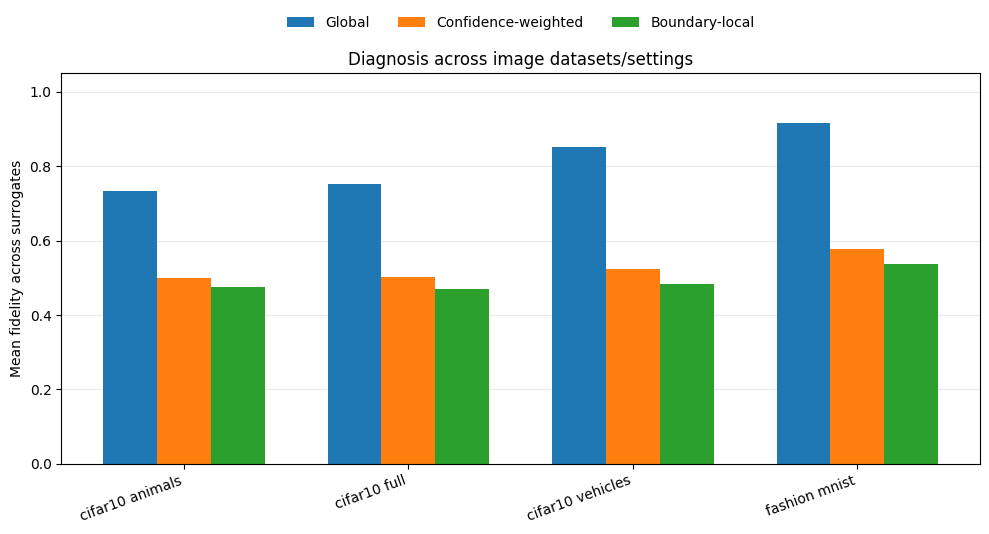

In [55]:
# -----------------------------------------------------------------------------
# Plot: global/boundary/weighted by dataset
# -----------------------------------------------------------------------------

plot_df = dataset_diagnosis.copy()
positions = np.arange(len(plot_df))
width = 0.24

fig, ax = plt.subplots(figsize=(10, 5.5), facecolor="white")
ax.set_facecolor("white")

ax.bar(positions - width, plot_df["global_fidelity_mean"], width, label="Global")
ax.bar(positions, plot_df["confidence_weighted_mean"], width, label="Confidence-weighted")
ax.bar(positions + width, plot_df["boundary_fidelity_mean"], width, label="Boundary-local")

ax.set_xticks(positions)
ax.set_xticklabels([pretty(x) for x in plot_df["dataset"]], rotation=20, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Mean fidelity across surrogates")
ax.set_title("Diagnosis across image datasets/settings")
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.18), ncol=3, frameon=False)
plt.tight_layout()
savefig("wider_global_boundary_weighted_by_dataset.png")
plt.show()


Saved wider_surrogate_selection_outputs/wider_confidence_stratified_by_dataset.png


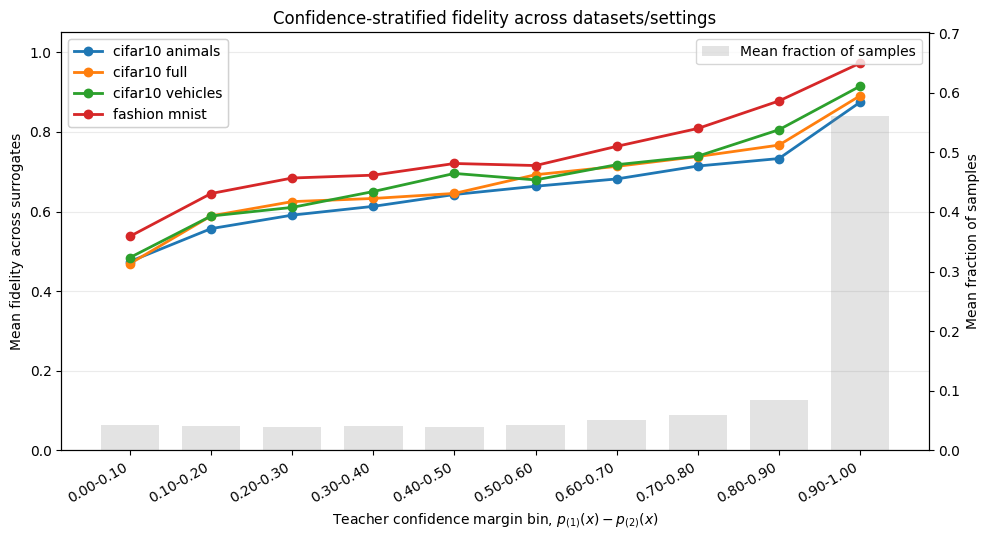

In [56]:
# -----------------------------------------------------------------------------
# Plot: confidence-stratified fidelity by dataset
# -----------------------------------------------------------------------------

combined_bins = (
    confidence_bins
    .groupby(["dataset", "bin", "bin_left"], as_index=False)
    .agg(
        fidelity_mean=("fidelity", "mean"),
        fraction_mean=("fraction", "mean"),
    )
    .sort_values(["dataset", "bin_left"])
)

# Average sample mass per confidence bin across datasets/settings.
# This is plotted as a background bar chart to show how much of the
# evaluation set lies in each teacher-confidence region.
mean_bin_mass = (
    combined_bins
    .groupby(["bin", "bin_left"], as_index=False)
    .agg(fraction_mean=("fraction_mean", "mean"))
    .sort_values("bin_left")
)

bin_order = mean_bin_mass["bin"].tolist()
x = np.arange(len(bin_order))

fig, ax = plt.subplots(figsize=(10, 5.5), facecolor="white")
ax.set_facecolor("white")

# Secondary axis: sample fractions as light gray bars.
ax_frac = ax.twinx()
ax_frac.bar(
    x,
    mean_bin_mass["fraction_mean"],
    width=0.72,
    alpha=0.22,
    color="gray",
    label="Mean fraction of samples",
    zorder=0,
)
ax_frac.set_ylabel("Mean fraction of samples")
ax_frac.set_ylim(0, max(0.05, mean_bin_mass["fraction_mean"].max() * 1.25))
ax_frac.grid(False)

# Primary axis: fidelity curves
for dataset_name, group in combined_bins.groupby("dataset"):
    group = group.sort_values("bin_left")
    y = [
        group.loc[group["bin"] == bin_label, "fidelity_mean"].iloc[0]
        if (group["bin"] == bin_label).any()
        else np.nan
        for bin_label in bin_order
    ]
    ax.plot(
        x,
        y,
        marker="o",
        linewidth=2,
        label=pretty(dataset_name),
        zorder=3,
    )

ax.set_ylim(0, 1.05)
ax.set_xticks(x)
ax.set_xticklabels(bin_order, rotation=30, ha="right")
ax.set_xlabel(r"Teacher confidence margin bin, $p_{(1)}(x)-p_{(2)}(x)$")
ax.set_ylabel("Mean fidelity across surrogates")
ax.set_title("Confidence-stratified fidelity across datasets/settings")
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)

# Keep the line legend and bar legend separate but compact.
line_legend = ax.legend(frameon=True, loc="upper left")
ax.add_artist(line_legend)
ax_frac.legend(frameon=True, loc="upper right")

plt.tight_layout()
savefig("wider_confidence_stratified_by_dataset.png")
plt.show()


Saved wider_surrogate_selection_outputs/wider_surrogate_selection_flips.png


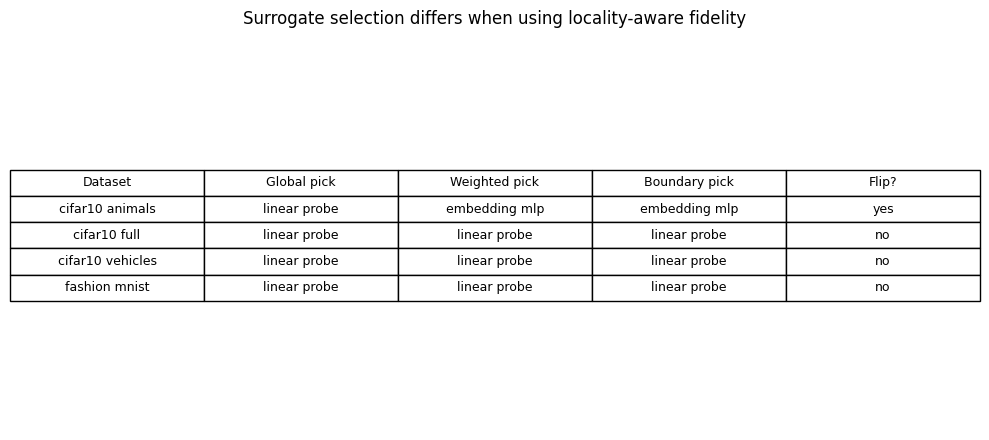

In [57]:
# -----------------------------------------------------------------------------
# Plot: surrogate selection flips
# -----------------------------------------------------------------------------

flip_df = selection_summary.copy()
flip_df["global_selected"] = flip_df["global_selected"].map(pretty)
flip_df["weighted_selected"] = flip_df["weighted_selected"].map(pretty)
flip_df["boundary_selected"] = flip_df["boundary_selected"].map(pretty)

fig, ax = plt.subplots(figsize=(10, 4.5), facecolor="white")
ax.axis("off")

table_data = flip_df[["dataset", "global_selected", "weighted_selected", "boundary_selected", "global_weighted_flip"]].copy()
table_data["dataset"] = table_data["dataset"].map(pretty)
table_data["global_weighted_flip"] = table_data["global_weighted_flip"].map(lambda x: "yes" if x else "no")

table = ax.table(
    cellText=table_data.values,
    colLabels=["Dataset", "Global pick", "Weighted pick", "Boundary pick", "Flip?"],
    cellLoc="center",
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.4)
ax.set_title("Surrogate selection differs when using locality-aware fidelity", pad=12)
plt.tight_layout()
savefig("wider_surrogate_selection_flips.png")
plt.show()


Saved wider_surrogate_selection_outputs/wider_metric_alignment_by_dataset.png


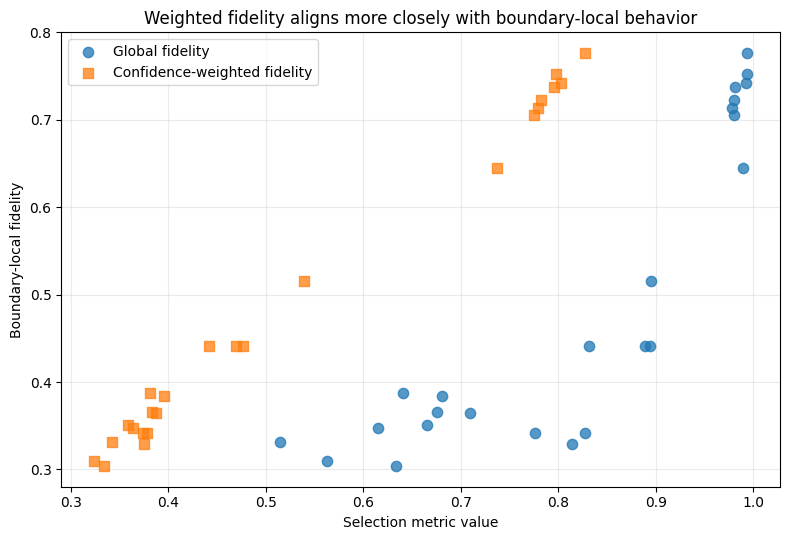

In [58]:
# -----------------------------------------------------------------------------
# Plot: metric alignment with boundary-local behavior
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5.5), facecolor="white")
ax.set_facecolor("white")

ax.scatter(results["global_fidelity"], results["boundary_fidelity"], s=55, alpha=0.75, label="Global fidelity")
ax.scatter(results["confidence_weighted_fidelity"], results["boundary_fidelity"], s=55, alpha=0.75, marker="s", label="Confidence-weighted fidelity")

ax.set_xlabel("Selection metric value")
ax.set_ylabel("Boundary-local fidelity")
ax.set_title("Weighted fidelity aligns more closely with boundary-local behavior")
ax.grid(alpha=0.25)
ax.set_axisbelow(True)
ax.legend(frameon=True)
plt.tight_layout()
savefig("wider_metric_alignment_by_dataset.png")
plt.show()


In [59]:
# -----------------------------------------------------------------------------
# LaTeX table for selection summary
# -----------------------------------------------------------------------------

latex_df = selection_summary.copy()
latex_df["dataset"] = latex_df["dataset"].map(pretty)
for col in ["global_selected", "weighted_selected", "boundary_selected"]:
    latex_df[col] = latex_df[col].map(pretty)
latex_df["global_weighted_flip"] = latex_df["global_weighted_flip"].map(lambda x: "Yes" if x else "No")
latex_df = latex_df[["dataset", "global_selected", "weighted_selected", "boundary_selected", "global_weighted_flip"]]
latex_df = latex_df.rename(columns={
    "dataset": "Dataset",
    "global_selected": "Global pick",
    "weighted_selected": "Weighted pick",
    "boundary_selected": "Boundary pick",
    "global_weighted_flip": "Flip?",
})

latex_table = latex_df.to_latex(index=False, escape=False)
with open(os.path.join(OUT_DIR, "wider_selection_latex_table.txt"), "w") as f:
    f.write(latex_table)

print(latex_table)


\begin{tabular}{lllll}
\toprule
Dataset & Global pick & Weighted pick & Boundary pick & Flip? \\
\midrule
cifar10 animals & linear probe & embedding mlp & embedding mlp & Yes \\
cifar10 full & linear probe & linear probe & linear probe & No \\
cifar10 vehicles & linear probe & linear probe & linear probe & No \\
fashion mnist & linear probe & linear probe & linear probe & No \\
\bottomrule
\end{tabular}



In [60]:
print("Done. Outputs saved in", OUT_DIR)

Done. Outputs saved in wider_surrogate_selection_outputs
